In [2]:
from scipy.io import loadmat 
    
data = loadmat('/home/jovyan/work/__shared/exam_projects/spike_threshold/rawdata01.mat') 
   
d = data['d']  
si = data['si'].item()
    
d.shape, si 

((1010101, 2), 99)

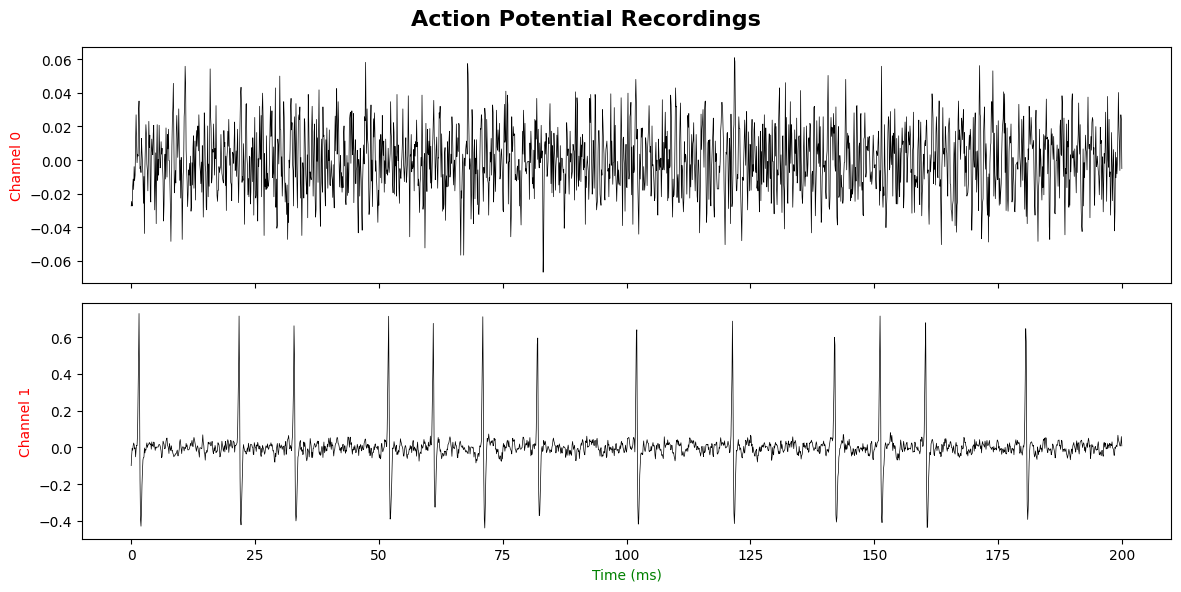

In [7]:
import numpy as np
import matplotlib.pyplot as plt
  
si_ms = si / 1000
t = np.arange(d.shape[0]) * si_ms 

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
mask = t < 2000  
    
fig.suptitle('Action Potential Recordings', fontsize=16, fontweight='bold')

for ch in range(2):
    axes[ch].plot(t[mask], d[mask, ch], lw=0.5, color='black')
    axes[ch].set_ylabel(f'Channel {ch}', color='red')

axes[-1].set_xlabel('Time (ms)', color='green')
plt.tight_layout()
plt.show()

In [4]:
def spike_detect(d, si, thresholds, si_unit='us'):
   
    if si_unit == 'us':
        si_ms = si / 1000.0
    else:
        si_ms = si

    n_samples = d.shape[0]
    n_channels = d.shape[1]
    
    tsl = {}  

    for ch in range(n_channels):
        channel_data = d[:, ch]
        thr = thresholds[ch]
        spike_times = []
        
        for i in range(1, n_samples):
            previous_value = channel_data[i - 1]
            current_value = channel_data[i]

            if thr >= 0:
                just_crossed = (previous_value < thr) and (current_value >= thr)
            else:
                just_crossed = (previous_value > thr) and (current_value <= thr)

            if just_crossed:
                spike_time = i * si_ms  
                spike_times.append(spike_time)
           
        tsl[ch] = np.array(spike_times)
    
    return tsl

In [5]:
def auto_threshold(x, k=4):
    #Automatically figure out a good threshold for spike detection, and decide whether spikes go up (positive) or down (negative).
    #x=the signal for one channel
    #k=how many "noise units" away from the middle counts as a spike
   
    median = np.median(x) 
    #find the "middle" of the signal (the typical baseline value)
    mad = np.median(np.abs(x - median))
    scale = mad / 0.6745  # rescale MAD to behave like an SD under Gaussian noise
 
    n_pos = np.sum(x > median + k * scale)
    n_neg = np.sum(x < median - k * scale)
 
    # whichever side has more extreme events is the real spike direction
    if n_neg > n_pos:
        return median - k * scale   # negative-going spikes
    else:
        return median + k * scale   # positive-going spikes
        
 #Q: Question is do we really need this auto-detect threshold 

In [6]:
thresholds = [auto_threshold(d[:, ch], k=4) for ch in range(d.shape[1])]
print("Auto thresholds:", thresholds)

tsl = spike_detect(d, si, thresholds, si_unit='us')

for ch, times in tsl.items():
    print(f"Channel {ch}: {len(times)} spikes detected")

Auto thresholds: [np.float32(-0.07412898), np.float32(-0.10926757)]
Channel 0: 564 spikes detected
Channel 1: 2386 spikes detected


In [26]:
for ch, times in tsl.items():
    isi = np.diff(times)
    print(f"Channel {ch}: min ISI = {isi.min():.3f} ms, n spikes = {len(times)}")
    #ISI = inter-spike interval, to check the gap 

Channel 0: min ISI = 0.198 ms, n spikes = 564
Channel 1: min ISI = 0.594 ms, n spikes = 2386


In [27]:
def apply_refractory(times, min_isi_ms):
    if len(times) == 0:
        return times
    keep = [times[0]]
    for t_spike in times[1:]:
        if t_spike - keep[-1] >= min_isi_ms:
            keep.append(t_spike)
    return np.array(keep)

# apply a 1 ms refractory period to both channels
for ch in tsl:
    tsl[ch] = apply_refractory(tsl[ch], min_isi_ms=1.0)

for ch, times in tsl.items():
    isi = np.diff(times)
    print(f"Channel {ch}: {len(times)} spikes, min ISI = {isi.min():.3f} ms")

Channel 0: 487 spikes, min ISI = 1.089 ms
Channel 1: 2385 spikes, min ISI = 1.188 ms


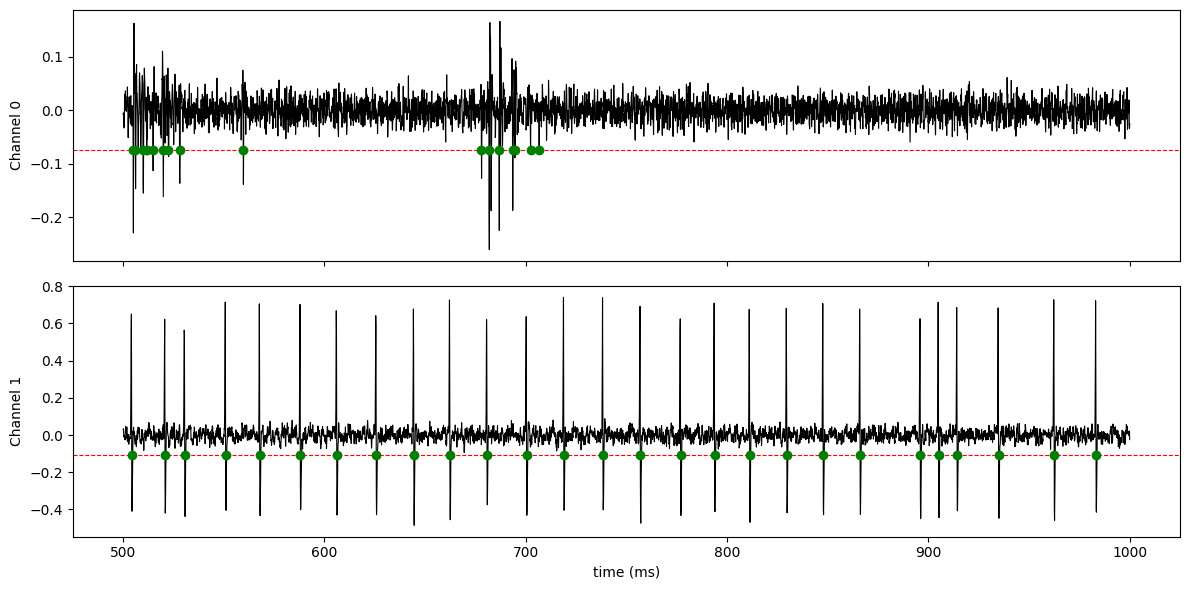

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
mask = (t > 500) & (t < 1000)

for ch in range(2):
    axes[ch].plot(t[mask], d[mask, ch], lw=0.8, color='black')
    axes[ch].axhline(thresholds[ch], color='r', ls='--', lw=0.8)
    times_in_range = tsl[ch][(tsl[ch] > 500) & (tsl[ch] < 1000)]
    axes[ch].plot(times_in_range, [thresholds[ch]]*len(times_in_range), 'go', ms=6)
    axes[ch].set_ylabel(f'Channel {ch}')

axes[-1].set_xlabel('time (ms)')
plt.tight_layout()
plt.show()

In [18]:
for ch, times in tsl.items():
    print(f"--- Channel {ch} time stamp list (ms) ---")
    for time_val in times[:10]:  # just show first 10 for a quick look
        print(f"{time_val:.1f}")
    print(f"... ({len(times)} total)\n")

--- Channel 0 time stamp list (ms) ---
488.5
493.4
505.0
506.1
509.9
511.7
514.9
519.9
522.5
528.1
... (487 total)

--- Channel 1 time stamp list (ms) ---
1.8
22.0
33.2
52.2
61.2
71.2
82.3
102.3
121.7
142.3
... (2385 total)

